In [1]:
 #CELL 1: Install Required Libraries
# ============================================================


!pip install pandas numpy scikit-learn xgboost matplotlib seaborn shap imbalanced-learn

print("✓ Libraries installation complete!")



✓ Libraries installation complete!


In [2]:
# ============================================================
# CELL 2: Import Libraries
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ML Libraries
import sklearn
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_recall_fscore_support, roc_auc_score, roc_curve,
    mean_absolute_error, mean_squared_error, r2_score
)

import xgboost as xgb
from imblearn.over_sampling import SMOTE
import joblib

# Visualization settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ All libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")
print(f"XGBoost version: {xgb.__version__}")

✓ All libraries imported successfully!
Pandas version: 2.2.2
NumPy version: 2.0.2
Scikit-learn version: 1.6.1
XGBoost version: 3.1.2


In [3]:
# ============================================================
# CELL 3: Load Datasets
# ============================================================

print("Loading datasets...")

# Load the CSV files
try:
    dogs_df = pd.read_csv('data/DOG_PROFILES.csv')
    pairs_df = pd.read_csv('data/COMPATIBILITY_PAIRS.csv')

    print(f"✓ DOG_PROFILES.csv loaded: {dogs_df.shape}")
    print(f"✓ COMPATIBILITY_PAIRS.csv loaded: {pairs_df.shape}")

    # Display first few rows
    print("\n--- Dog Profiles Sample ---")
    display(dogs_df.head(3))

    print("\n--- Compatibility Pairs Sample ---")
    display(pairs_df.head(3))

except FileNotFoundError as e:
    print("❌ ERROR: CSV files not found!")
    print("Please run the dataset generator script first.")
    raise e

Loading datasets...
✓ DOG_PROFILES.csv loaded: (1600, 24)
✓ COMPATIBILITY_PAIRS.csv loaded: (12000, 30)

--- Dog Profiles Sample ---


,dog_id,breed,age_months,gender,weight_kg,height_cm,body_size_category,bone_structure_score,hip_dysplasia_risk,elbow_dysplasia_risk,...,temperament_score,energy_level,genetic_diversity_coi,previous_litters,last_breeding_months_ago,lineage_health_score,vet_certified,breeding_eligible,is_invalid,invalid_reason
0,DOG_GE_0001,German Shepherd,32,Male,28.7,64.5,Large,8.6,0.080,0.215,...,7.1,5,0.195,0,NaN,9.4,True,True,False,NaN
1,DOG_GE_0002,German Shepherd,35,Male,25.8,56.8,Large,6.6,0.215,0.036,...,7.4,4,0.094,0,NaN,9.3,True,True,False,NaN
2,DOG_GE_0003,German Shepherd,22,Male,30.2,62.9,Large,6.7,0.447,0.221,...,7.2,4,0.192,0,NaN,8.9,True,True,False,NaN



--- Compatibility Pairs Sample ---


,pair_id,dog_1_id,dog_2_id,dog_1_breed,dog_2_breed,dog_1_gender,dog_2_gender,same_gender,dog_1_age_months,dog_2_age_months,...,temperament_match_score,combined_hip_risk,combined_eye_risk,combined_heart_risk,overall_compatibility_score,breeding_recommended,risk_level,risk_factors,expected_offspring_health,has_critical_issue
0,PAIR_00001,DOG_LA_0186,DOG_MI_0390,Labrador,Mixed,Female,Male,False,75,22,...,8.9,0.127,0.011,0.005,18.2,No,High,"['Extreme age gap (53mo)', 'Extreme size misma...",0.0,True
1,PAIR_00002,DOG_MI_0332,DOG_DA_0303,Mixed,Dachshund,Female,Male,False,128,28,...,8.8,0.087,0.057,0.036,0.8,No,High,['Dog 1 age (128mo) outside breeding range (18...,0.0,True
2,PAIR_00003,DOG_LA_0270,DOG_GE_0367,Labrador,German Shepherd,Female,Male,False,24,123,...,8.8,0.141,0.031,0.078,18.4,No,High,['Dog 2 age (123mo) outside breeding range (18...,0.0,True


EXPLORATORY DATA ANALYSIS

1. Dataset Overview:
   Total dogs: 1600
   Total pairs: 12000

2. Breed Distribution:
breed
German Shepherd    400
Labrador           400
Dachshund          400
Mixed              400
Name: count, dtype: int64

3. Gender Distribution:
gender
Female    805
Male      795
Name: count, dtype: int64

4. Compatibility Pair Distribution:
   Same Gender Pairs: 6592 (54.9%)
   Opposite Gender Pairs: 5408 (45.1%)

5. Breeding Recommendation Distribution:
breeding_recommended
No         8566
Yes        3425
Caution       9
Name: count, dtype: int64

6. Risk Level Distribution:
risk_level
High      8566
Low       3425
Medium       9
Name: count, dtype: int64


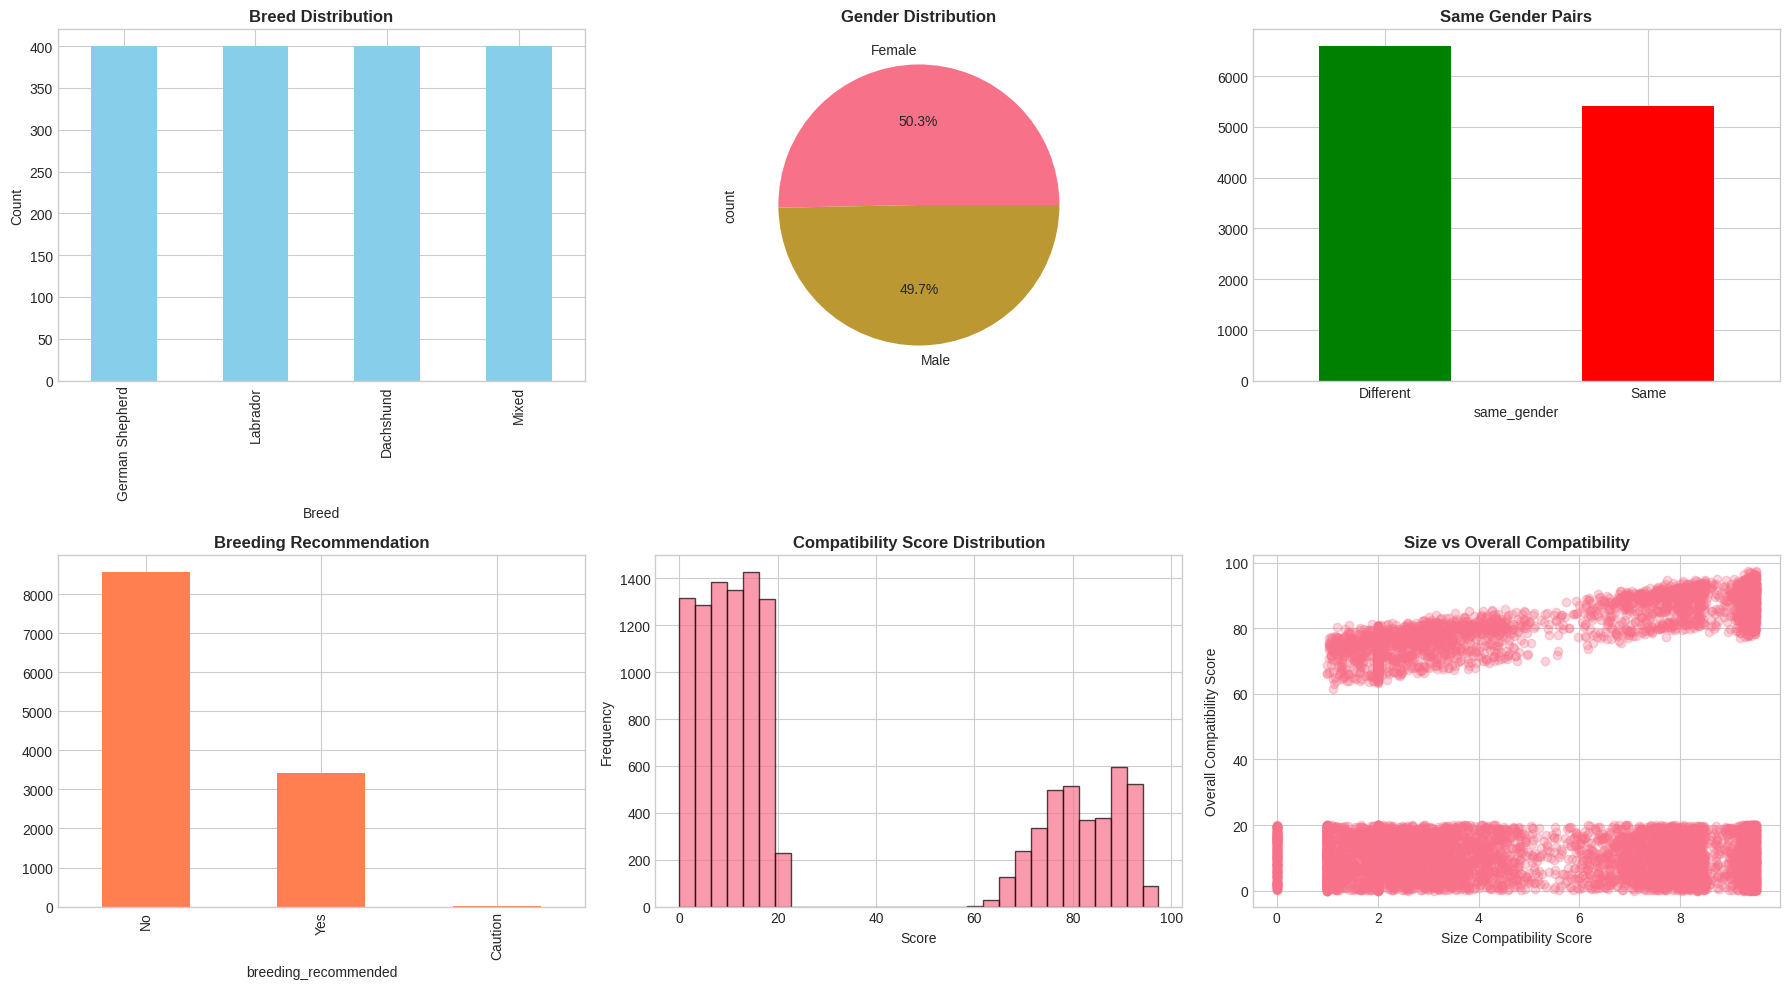


✓ EDA complete! Saved: eda_overview.png


In [4]:
# ============================================================
# CELL 4: Exploratory Data Analysis (EDA)
# ============================================================

print("="*80)
print("EXPLORATORY DATA ANALYSIS")
print("="*80)

# Dataset statistics
print("\n1. Dataset Overview:")
print(f"   Total dogs: {len(dogs_df)}")
print(f"   Total pairs: {len(pairs_df)}")

print("\n2. Breed Distribution:")
print(dogs_df['breed'].value_counts())

print("\n3. Gender Distribution:")
print(dogs_df['gender'].value_counts())

print("\n4. Compatibility Pair Distribution:")
print(f"   Same Gender Pairs: {pairs_df['same_gender'].sum()} ({pairs_df['same_gender'].sum()/len(pairs_df)*100:.1f}%)")
print(f"   Opposite Gender Pairs: {(~pairs_df['same_gender']).sum()} ({(~pairs_df['same_gender']).sum()/len(pairs_df)*100:.1f}%)")

print("\n5. Breeding Recommendation Distribution:")
print(pairs_df['breeding_recommended'].value_counts())

print("\n6. Risk Level Distribution:")
print(pairs_df['risk_level'].value_counts())

# Visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Plot 1: Breed distribution
dogs_df['breed'].value_counts().plot(kind='bar', ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Breed Distribution', fontweight='bold')
axes[0,0].set_xlabel('Breed')
axes[0,0].set_ylabel('Count')

# Plot 2: Gender distribution
dogs_df['gender'].value_counts().plot(kind='pie', ax=axes[0,1], autopct='%1.1f%%')
axes[0,1].set_title('Gender Distribution', fontweight='bold')

# Plot 3: Same gender pairs
pairs_df['same_gender'].value_counts().plot(kind='bar', ax=axes[0,2], color=['green', 'red'])
axes[0,2].set_title('Same Gender Pairs', fontweight='bold')
axes[0,2].set_xticklabels(['Different', 'Same'], rotation=0)

# Plot 4: Breeding recommendation
pairs_df['breeding_recommended'].value_counts().plot(kind='bar', ax=axes[1,0], color='coral')
axes[1,0].set_title('Breeding Recommendation', fontweight='bold')

# Plot 5: Compatibility score distribution
axes[1,1].hist(pairs_df['overall_compatibility_score'], bins=30, edgecolor='black', alpha=0.7)
axes[1,1].set_title('Compatibility Score Distribution', fontweight='bold')
axes[1,1].set_xlabel('Score')
axes[1,1].set_ylabel('Frequency')

# Plot 6: Size compatibility vs overall score
axes[1,2].scatter(pairs_df['size_compatibility_score'],
                  pairs_df['overall_compatibility_score'], alpha=0.3)
axes[1,2].set_title('Size vs Overall Compatibility', fontweight='bold')
axes[1,2].set_xlabel('Size Compatibility Score')
axes[1,2].set_ylabel('Overall Compatibility Score')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ EDA complete! Saved: eda_overview.png")

In [5]:
# ============================================================
# CELL 5: Feature Engineering
# ============================================================

print("="*80)
print("FEATURE ENGINEERING")
print("="*80)

# Create feature matrix
X = pairs_df[[
    'dog_1_age_months',
    'dog_2_age_months',
    'age_gap_months',
    'dog_1_weight_kg',
    'dog_2_weight_kg',
    'weight_ratio',
    'size_compatibility_score',
    'age_compatibility_score',
    'genetic_diversity_score',
    'health_compatibility_score',
    'temperament_match_score',
    'combined_hip_risk',
    'combined_eye_risk',
    'combined_heart_risk'
]].copy()

# Add age validation features
X['dog_1_too_young'] = (pairs_df['dog_1_age_months'] < 18).astype(int)
X['dog_2_too_young'] = (pairs_df['dog_2_age_months'] < 18).astype(int)
X['dog_1_too_old'] = (pairs_df['dog_1_age_months'] > 96).astype(int)
X['dog_2_too_old'] = (pairs_df['dog_2_age_months'] > 96).astype(int)
X['extreme_age_gap'] = (X['age_gap_months'] > 48).astype(int)
X['extreme_weight_ratio'] = (X['weight_ratio'] > 4.0).astype(int)

print(f"✓ Added 6 new validation features")
print(f"  Total features: {len(X.columns)}")

# CRITICAL: Add same_gender feature
X['same_gender'] = pairs_df['same_gender'].astype(int)
print("✓ Added 'same_gender' feature (0=different, 1=same)")

# Add breed-related features
X['same_breed'] = (pairs_df['dog_1_breed'] == pairs_df['dog_2_breed']).astype(int)
X['has_mixed'] = ((pairs_df['dog_1_breed'] == 'Mixed') |
                   (pairs_df['dog_2_breed'] == 'Mixed')).astype(int)

# Encode breed pairs
breed_pairs = pairs_df['dog_1_breed'] + '_x_' + pairs_df['dog_2_breed']
le_breed = LabelEncoder()
X['breed_pair_encoded'] = le_breed.fit_transform(breed_pairs)

# Add size category features
size_map = {'Small': 1, 'Medium': 2, 'Large': 3}
X['dog_1_size_encoded'] = pairs_df['dog_1_size_category'].map(size_map)
X['dog_2_size_encoded'] = pairs_df['dog_2_size_category'].map(size_map)
X['size_difference'] = abs(X['dog_1_size_encoded'] - X['dog_2_size_encoded'])

# Interaction features
X['genetic_health_interaction'] = X['genetic_diversity_score'] * X['health_compatibility_score']
X['size_age_interaction'] = X['size_compatibility_score'] * X['age_compatibility_score']

print(f"\n✓ Feature matrix created: {X.shape}")
print(f"  Total features: {len(X.columns)}")
print(f"\nFeatures: {list(X.columns)}")

# Target variables
y_recommendation = pairs_df['breeding_recommended']
y_score = pairs_df['overall_compatibility_score']
y_risk = pairs_df['risk_level']

# Encode categorical targets
le_recommendation = LabelEncoder()
le_risk = LabelEncoder()
y_recommendation_encoded = le_recommendation.fit_transform(y_recommendation)
y_risk_encoded = le_risk.fit_transform(y_risk)

print(f"\n✓ Target variables encoded:")
print(f"  Recommendation classes: {le_recommendation.classes_}")
print(f"  Risk classes: {le_risk.classes_}")

# Check for missing values
print(f"\n✓ Missing values check:")
print(X.isnull().sum()[X.isnull().sum() > 0])
if X.isnull().sum().sum() == 0:
    print("  No missing values found!")

FEATURE ENGINEERING
✓ Added 6 new validation features
  Total features: 20
✓ Added 'same_gender' feature (0=different, 1=same)

✓ Feature matrix created: (12000, 29)
  Total features: 29

Features: ['dog_1_age_months', 'dog_2_age_months', 'age_gap_months', 'dog_1_weight_kg', 'dog_2_weight_kg', 'weight_ratio', 'size_compatibility_score', 'age_compatibility_score', 'genetic_diversity_score', 'health_compatibility_score', 'temperament_match_score', 'combined_hip_risk', 'combined_eye_risk', 'combined_heart_risk', 'dog_1_too_young', 'dog_2_too_young', 'dog_1_too_old', 'dog_2_too_old', 'extreme_age_gap', 'extreme_weight_ratio', 'same_gender', 'same_breed', 'has_mixed', 'breed_pair_encoded', 'dog_1_size_encoded', 'dog_2_size_encoded', 'size_difference', 'genetic_health_interaction', 'size_age_interaction']

✓ Target variables encoded:
  Recommendation classes: ['Caution' 'No' 'Yes']
  Risk classes: ['High' 'Low' 'Medium']

✓ Missing values check:
Series([], dtype: int64)
  No missing values f

In [6]:
# ============================================================
# CELL 6: Train-Test-Validation Split
# ============================================================

print("="*80)
print("SPLITTING DATA")
print("="*80)

# Split: 70% train, 15% validation, 15% test
print("\nSplitting data: 70% train, 15% validation, 15% test")

# First split: 70% train, 30% temp
X_train, X_temp, y_rec_train, y_rec_temp, y_score_train, y_score_temp, y_risk_train, y_risk_temp = train_test_split(
    X, y_recommendation_encoded, y_score, y_risk_encoded,
    test_size=0.30, random_state=42, stratify=y_recommendation_encoded
)

# Store original training data before potential SMOTE for other models
X_train_original = X_train.copy()
y_rec_train_original = y_rec_train.copy()
y_score_train_original = y_score_train.copy()
y_risk_train_original = y_risk_train.copy()

# Second split: 50% of temp (15% val, 15% test)
X_val, X_test, y_rec_val, y_rec_test, y_score_val, y_score_test, y_risk_val, y_risk_test = train_test_split(
    X_temp, y_rec_temp, y_score_temp, y_risk_temp,
    test_size=0.50, random_state=42, stratify=y_rec_temp
)

print(f"\n✓ Training set: {X_train.shape[0]} samples")
print(f"✓ Validation set: {X_val.shape[0]} samples")
print(f"✓ Test set: {X_test.shape[0]} samples")

# Check class distribution
print("\n✓ Class distribution in training set:")
unique, counts = np.unique(y_rec_train, return_counts=True)
for cls, count in zip(le_recommendation.classes_[unique], counts):
    print(f"  {cls}: {count} ({count/len(y_rec_train)*100:.1f}%)")


SPLITTING DATA

Splitting data: 70% train, 15% validation, 15% test

✓ Training set: 8400 samples
✓ Validation set: 1800 samples
✓ Test set: 1800 samples

✓ Class distribution in training set:
  Caution: 6 (0.1%)
  No: 5996 (71.4%)
  Yes: 2398 (28.5%)


In [7]:
# ============================================================
# CELL 7: Handle Class Imbalance (Optional)
# ============================================================

print("="*80)
print("HANDLING CLASS IMBALANCE (if needed)")
print("="*80)

# Check if  need SMOTE
class_counts = pd.Series(y_rec_train).value_counts()
imbalance_ratio = class_counts.max() / class_counts.min()

print(f"Imbalance ratio: {imbalance_ratio:.2f}")

if imbalance_ratio > 3:
    print("⚠️  Significant class imbalance detected. Applying SMOTE...")
    smote = SMOTE(random_state=42)
    X_train_balanced, y_rec_train_balanced = smote.fit_resample(X_train, y_rec_train)

    print(f"✓ Before SMOTE: {X_train.shape[0]} samples")
    print(f"✓ After SMOTE: {X_train_balanced.shape[0]} samples")

    # Use balanced data
    X_train = X_train_balanced
    y_rec_train = y_rec_train_balanced
else:
    print("✓ Class distribution is acceptable. No balancing needed.")


HANDLING CLASS IMBALANCE (if needed)
Imbalance ratio: 999.33
⚠️  Significant class imbalance detected. Applying SMOTE...
✓ Before SMOTE: 8400 samples
✓ After SMOTE: 17988 samples


In [8]:
#============================================================
# CELL 8: Model 1 - Baseline Logistic Regression
# ============================================================

print("="*80)
print("MODEL 1: BASELINE - LOGISTIC REGRESSION")
print("="*80)

# Train baseline model
lr_model = LogisticRegression(random_state=42, max_iter=1000, multi_class='multinomial')
lr_model.fit(X_train, y_rec_train)

# Predictions
y_rec_pred_lr = lr_model.predict(X_val)
accuracy_lr = accuracy_score(y_rec_val, y_rec_pred_lr)

print(f"\n✓ Validation Accuracy: {accuracy_lr:.4f}")

print("\n--- Classification Report ---")
print(classification_report(y_rec_val, y_rec_pred_lr,
                          target_names=le_recommendation.classes_))

MODEL 1: BASELINE - LOGISTIC REGRESSION

✓ Validation Accuracy: 0.9872

--- Classification Report ---
              precision    recall  f1-score   support

     Caution       0.00      0.00      0.00         1
          No       1.00      0.99      0.99      1285
         Yes       0.97      0.99      0.98       514

    accuracy                           0.99      1800
   macro avg       0.66      0.66      0.66      1800
weighted avg       0.99      0.99      0.99      1800



In [10]:
# ============================================================
# CELL 9: Model 2 - Random Forest Classifier
# ============================================================

print("="*80)
print("MODEL 2: RANDOM FOREST CLASSIFIER (Breeding Recommendation)")
print("="*80)

#=======start Timer=======
from datetime import datetime
import time
print(f"⏰ Started: {datetime.now().strftime('%H:%M:%S')}")
cell_start_time = time.time()

# Hyperparameter grid
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', None]  # Help with imbalance
}

total_combinations = np.prod([len(v) for v in param_grid_rf.values()])
print(f"📊 Total combinations to test: {total_combinations}")
print("⏳ Estimated time: 5-10 minutes")
print("   (Grab a coffee ☕ while this runs...)\n")

# Initialize model
rf_classifier = RandomForestClassifier(random_state=42, n_jobs=-1)

print("⏳ Performing GridSearchCV (this may take 5-10 minutes)...")
print("   Grid size:", np.prod([len(v) for v in param_grid_rf.values()]), "combinations")

# Grid search with cross-validation
grid_search_rf = GridSearchCV(
    rf_classifier, param_grid_rf, cv=5,
    scoring='accuracy', n_jobs=-1, verbose=2
)
grid_search_rf.fit(X_train, y_rec_train)

# END TIMER
cell_end_time = time.time()
elapsed_seconds = cell_end_time - cell_start_time
elapsed_minutes = elapsed_seconds / 60


# Best model
best_rf_classifier = grid_search_rf.best_estimator_

print(f"\n✓ Best Parameters: {grid_search_rf.best_params_}")
print(f"✓ Best CV Score: {grid_search_rf.best_score_:.4f}")

# Evaluate on validation set
y_rec_pred_rf = best_rf_classifier.predict(X_val)
y_rec_proba_rf = best_rf_classifier.predict_proba(X_val)
accuracy_rf = accuracy_score(y_rec_val, y_rec_pred_rf)

print(f"\n✓ Validation Accuracy: {accuracy_rf:.4f}")

print("\n--- Classification Report ---")
print(classification_report(y_rec_val, y_rec_pred_rf,
                          target_names=le_recommendation.classes_))

# Cross-validation scores
cv_scores = cross_val_score(best_rf_classifier, X_train, y_rec_train, cv=5, scoring='accuracy')
print(f"\n✓ 5-Fold CV Scores: {cv_scores}")
print(f"✓ Mean CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")


MODEL 2: RANDOM FOREST CLASSIFIER (Breeding Recommendation)
⏰ Started: 04:02:22
📊 Total combinations to test: 216
⏳ Estimated time: 5-10 minutes
   (Grab a coffee ☕ while this runs...)

⏳ Performing GridSearchCV (this may take 5-10 minutes)...
   Grid size: 216 combinations
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

✓ Best Parameters: {'class_weight': None, 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
✓ Best CV Score: 0.9978

✓ Validation Accuracy: 0.9917

--- Classification Report ---
              precision    recall  f1-score   support

     Caution       0.00      0.00      0.00         1
          No       1.00      0.99      0.99      1285
         Yes       0.98      0.99      0.99       514

    accuracy                           0.99      1800
   macro avg       0.66      0.66      0.66      1800
weighted avg       0.99      0.99      0.99      1800


✓ 5-Fold CV Scores: [0.99694275 0.99694275 0.99861034 0.9986099

FEATURE IMPORTANCE ANALYSIS

--- Top 15 Most Important Features ---
                   feature  importance
               same_gender    0.311421
health_compatibility_score    0.156676
         combined_hip_risk    0.153210
      size_age_interaction    0.098573
genetic_health_interaction    0.050746
   age_compatibility_score    0.042950
  size_compatibility_score    0.035607
              weight_ratio    0.022454
           dog_1_weight_kg    0.021966
            age_gap_months    0.019558
           extreme_age_gap    0.018562
   genetic_diversity_score    0.013117
           size_difference    0.010180
                same_breed    0.008139
        breed_pair_encoded    0.005792


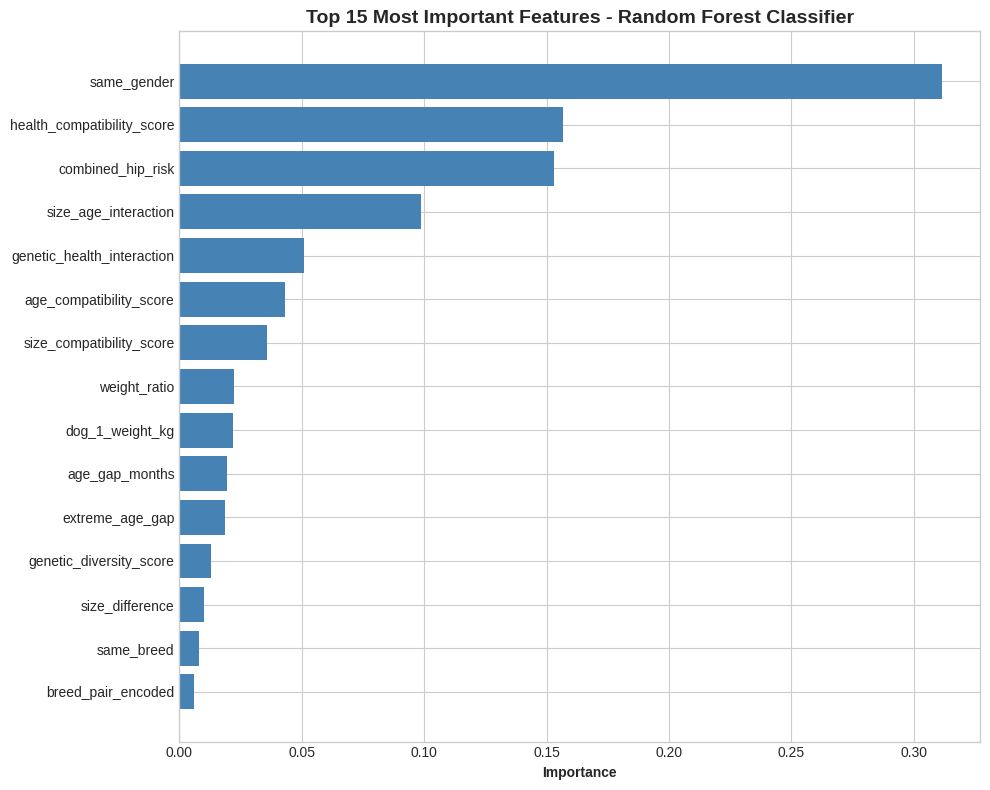


✓ Saved: feature_importance_rf.png

✅ 'same_gender' feature importance: 0.3114
   Rank: #21


In [11]:
# ============================================================
# CELL 10: Feature Importance Analysis
# ============================================================

print("="*80)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*80)

# Get feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': best_rf_classifier.feature_importances_
}).sort_values('importance', ascending=False)

print("\n--- Top 15 Most Important Features ---")
print(feature_importance.head(15).to_string(index=False))

# Visualize
plt.figure(figsize=(10, 8))
top_15 = feature_importance.head(15)
plt.barh(top_15['feature'], top_15['importance'], color='steelblue')
plt.xlabel('Importance', fontweight='bold')
plt.title('Top 15 Most Important Features - Random Forest Classifier',
          fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance_rf.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved: feature_importance_rf.png")

# Check if same_gender is important
same_gender_importance = feature_importance[feature_importance['feature'] == 'same_gender']['importance'].values[0]
print(f"\n✅ 'same_gender' feature importance: {same_gender_importance:.4f}")
print(f"   Rank: #{feature_importance[feature_importance['feature'] == 'same_gender'].index[0] + 1}")


CONFUSION MATRIX ANALYSIS


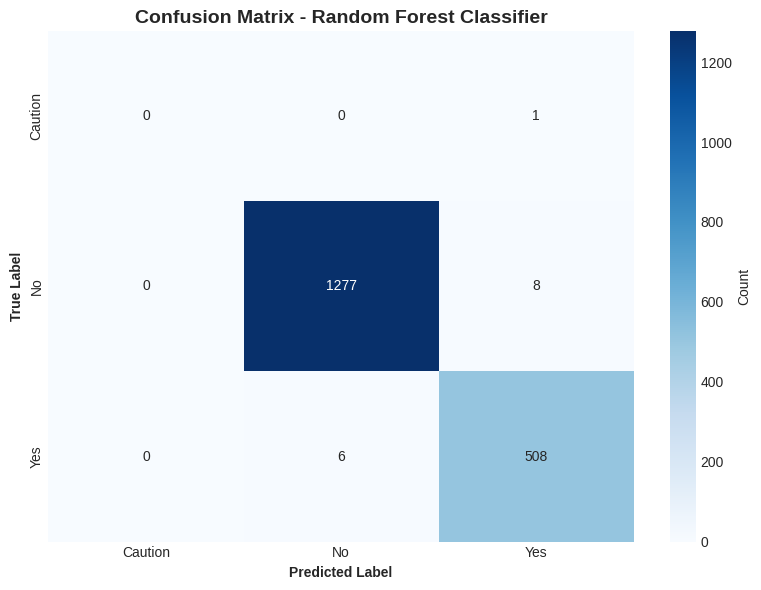

✓ Saved: confusion_matrix_rf.png

--- Per-Class Performance ---
Caution:
  Precision: 0.0000
  Recall: 0.0000
  F1-Score: 0.0000
  Support: 1
No:
  Precision: 0.9953
  Recall: 0.9938
  F1-Score: 0.9945
  Support: 1285
Yes:
  Precision: 0.9826
  Recall: 0.9883
  F1-Score: 0.9855
  Support: 514


In [12]:
# ============================================================
# CELL 11: Confusion Matrix Visualization
# ============================================================

print("="*80)
print("CONFUSION MATRIX ANALYSIS")
print("="*80)

# Compute confusion matrix
cm = confusion_matrix(y_rec_val, y_rec_pred_rf)

# Visualize
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_recommendation.classes_,
            yticklabels=le_recommendation.classes_,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Random Forest Classifier', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontweight='bold')
plt.xlabel('Predicted Label', fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_rf.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: confusion_matrix_rf.png")

# Detailed analysis
print("\n--- Per-Class Performance ---")
precision, recall, f1, support = precision_recall_fscore_support(y_rec_val, y_rec_pred_rf)
for i, cls in enumerate(le_recommendation.classes_):
    print(f"{cls}:")
    print(f"  Precision: {precision[i]:.4f}")
    print(f"  Recall: {recall[i]:.4f}")
    print(f"  F1-Score: {f1[i]:.4f}")
    print(f"  Support: {support[i]}")

In [13]:
# ============================================================
# CELL 12: Test Same-Gender Detection
# ============================================================

print("="*80)
print("TESTING SAME-GENDER DETECTION")
print("="*80)

# Filter validation set for same-gender pairs
same_gender_mask = X_val['same_gender'] == 1
X_val_same_gender = X_val[same_gender_mask]
y_rec_val_same_gender = y_rec_val[same_gender_mask]

if len(X_val_same_gender) > 0:
    y_pred_same_gender = best_rf_classifier.predict(X_val_same_gender)

    # Check how many are correctly classified as "No"
    no_class_idx = list(le_recommendation.classes_).index('No')
    correct_no = (y_pred_same_gender == no_class_idx).sum()

    print(f"\n✓ Same-gender pairs in validation set: {len(X_val_same_gender)}")
    print(f"✓ Correctly classified as 'No': {correct_no} ({correct_no/len(X_val_same_gender)*100:.1f}%)")

    print("\n--- Prediction Distribution for Same-Gender Pairs ---")
    pred_distribution = pd.Series(y_pred_same_gender).value_counts()
    for cls_idx, count in pred_distribution.items():
        cls_name = le_recommendation.classes_[cls_idx]
        print(f"  {cls_name}: {count} ({count/len(y_pred_same_gender)*100:.1f}%)")
else:
    print("⚠️  No same-gender pairs in validation set")

TESTING SAME-GENDER DETECTION

✓ Same-gender pairs in validation set: 977
✓ Correctly classified as 'No': 977 (100.0%)

--- Prediction Distribution for Same-Gender Pairs ---
  No: 977 (100.0%)


MODEL 3: RANDOM FOREST REGRESSOR (Compatibility Score)
📊 Total combinations: 48
⏳ Performing GridSearchCV...
Fitting 5 folds for each of 48 candidates, totalling 240 fits

✓ Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

✓ Validation Metrics:
  MAE: 3.75
  RMSE: 4.98
  R² Score: 0.9786


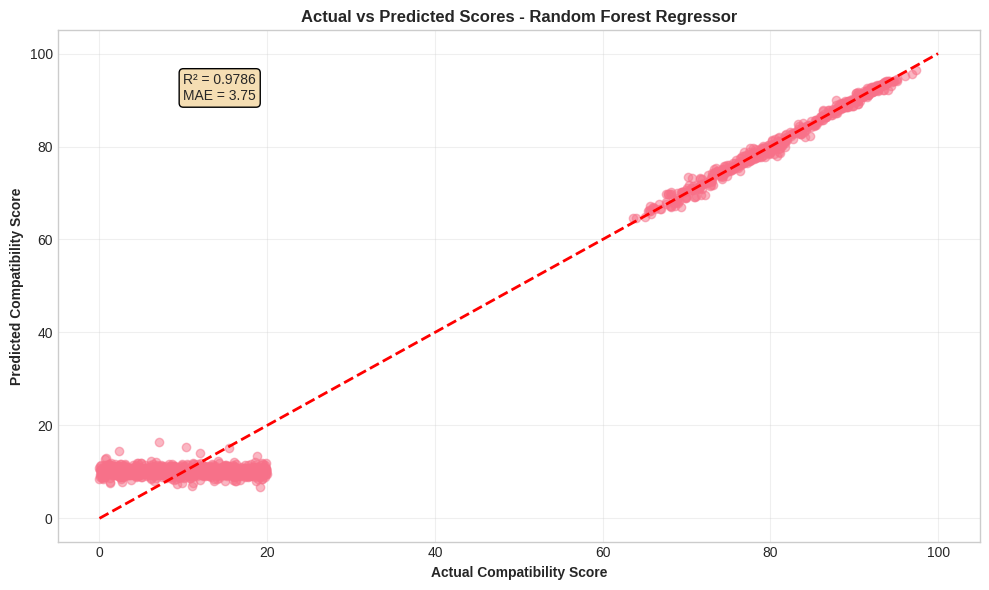


✓ Saved: regression_predictions.png


In [15]:
# ============================================================
# CELL 13: Model 3 - Random Forest Regressor (Compatibility Score)
# ============================================================

print("="*80)
print("MODEL 3: RANDOM FOREST REGRESSOR (Compatibility Score)")
print("="*80)



param_grid_reg = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

total_combinations = np.prod([len(v) for v in param_grid_reg.values()])
print(f"📊 Total combinations: {total_combinations}")

rf_regressor = RandomForestRegressor(random_state=42, n_jobs=-1)

print("⏳ Performing GridSearchCV...")
grid_search_reg = GridSearchCV(
    rf_regressor, param_grid_reg, cv=5,
    scoring='neg_mean_squared_error', n_jobs=-1, verbose=2
)
# Use original training data for regression model, as SMOTE was for classification target
grid_search_reg.fit(X_train_original, y_score_train_original)

# END TIMER
cell_end_time = time.time()
elapsed_seconds = cell_end_time - cell_start_time
elapsed_minutes = elapsed_seconds / 60

best_rf_regressor = grid_search_reg.best_estimator_

print(f"\n✓ Best Parameters: {grid_search_reg.best_params_}")

# Evaluate
y_score_pred = best_rf_regressor.predict(X_val)
mae = mean_absolute_error(y_score_val, y_score_pred)
rmse = np.sqrt(mean_squared_error(y_score_val, y_score_pred))
r2 = r2_score(y_score_val, y_score_pred)

print(f"\n✓ Validation Metrics:")
print(f"  MAE: {mae:.2f}")
print(f"  RMSE: {rmse:.2f}")
print(f"  R² Score: {r2:.4f}")

# Visualize predictions
plt.figure(figsize=(10, 6))
plt.scatter(y_score_val, y_score_pred, alpha=0.5)
plt.plot([0, 100], [0, 100], 'r--', lw=2)
plt.xlabel('Actual Compatibility Score', fontweight='bold')
plt.ylabel('Predicted Compatibility Score', fontweight='bold')
plt.title('Actual vs Predicted Scores - Random Forest Regressor', fontweight='bold')
plt.text(10, 90, f'R² = {r2:.4f}\nMAE = {mae:.2f}',
         bbox=dict(boxstyle='round', facecolor='wheat'))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('regression_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved: regression_predictions.png")


In [16]:
# ============================================================
# CELL 14: Model 4 - XGBoost Classifier (Risk Level)
# ============================================================

print("="*80)
print("MODEL 4: XGBOOST CLASSIFIER (Risk Level)")
print("="*80)

param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [5, 7, 10],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

xgb_classifier = xgb.XGBClassifier(random_state=42, eval_metric='mlogloss')

print("⏳ Performing GridSearchCV...")
grid_search_xgb = GridSearchCV(
    xgb_classifier, param_grid_xgb, cv=5,
    scoring='accuracy', n_jobs=-1, verbose=2
)
# Use original training data for risk model, as SMOTE was for a different classification target
grid_search_xgb.fit(X_train_original, y_risk_train_original)

best_xgb_classifier = grid_search_xgb.best_estimator_

print(f"\n✓ Best Parameters: {grid_search_xgb.best_params_}")

# Evaluate
y_risk_pred = best_xgb_classifier.predict(X_val)
accuracy_xgb = accuracy_score(y_risk_val, y_risk_pred)

print(f"\n✓ Validation Accuracy: {accuracy_xgb:.4f}")

print("\n--- Classification Report (Risk Level) ---")
print(classification_report(y_risk_val, y_risk_pred,
                          target_names=le_risk.classes_))


MODEL 4: XGBOOST CLASSIFIER (Risk Level)
⏳ Performing GridSearchCV...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

✓ Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}

✓ Validation Accuracy: 0.9950

--- Classification Report (Risk Level) ---
              precision    recall  f1-score   support

        High       1.00      1.00      1.00      1285
         Low       0.99      1.00      0.99       514
      Medium       0.00      0.00      0.00         1

    accuracy                           0.99      1800
   macro avg       0.66      0.66      0.66      1800
weighted avg       0.99      0.99      0.99      1800



In [17]:
# ============================================================
# CELL 15: FINAL EVALUATION ON TEST SET
# ============================================================

print("="*80)
print("FINAL EVALUATION ON TEST SET")
print("="*80)

# Model 1: Breeding Recommendation
y_rec_test_pred = best_rf_classifier.predict(X_test)
test_accuracy = accuracy_score(y_rec_test, y_rec_test_pred)

print(f"\n✓ Model 1 (Breeding Recommendation)")
print(f"  Test Accuracy: {test_accuracy:.4f}")
print("\n" + classification_report(y_rec_test, y_rec_test_pred,
                                    target_names=le_recommendation.classes_))

# Model 2: Compatibility Score
y_score_test_pred = best_rf_regressor.predict(X_test)
test_mae = mean_absolute_error(y_score_test, y_score_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_score_test, y_score_test_pred))
test_r2 = r2_score(y_score_test, y_score_test_pred)

print(f"\n✓ Model 2 (Compatibility Score)")
print(f"  MAE: {test_mae:.2f}")
print(f"  RMSE: {test_rmse:.2f}")
print(f"  R²: {test_r2:.4f}")

# Model 3: Risk Level
y_risk_test_pred = best_xgb_classifier.predict(X_test)
test_risk_accuracy = accuracy_score(y_risk_test, y_risk_test_pred)

print(f"\n✓ Model 3 (Risk Level)")
print(f"  Test Accuracy: {test_risk_accuracy:.4f}")


FINAL EVALUATION ON TEST SET

✓ Model 1 (Breeding Recommendation)
  Test Accuracy: 0.9911

              precision    recall  f1-score   support

     Caution       0.00      0.00      0.00         2
          No       1.00      0.99      0.99      1285
         Yes       0.98      0.99      0.98       513

    accuracy                           0.99      1800
   macro avg       0.66      0.66      0.66      1800
weighted avg       0.99      0.99      0.99      1800


✓ Model 2 (Compatibility Score)
  MAE: 3.59
  RMSE: 4.91
  R²: 0.9787

✓ Model 3 (Risk Level)
  Test Accuracy: 0.9967


In [18]:
# ============================================================
# CELL 16: Save All Models
# ============================================================

print("="*80)
print("SAVING TRAINED MODELS")
print("="*80)

# Save models
joblib.dump(best_rf_classifier, 'rf_classifier_breeding.pkl')
joblib.dump(best_rf_regressor, 'rf_regressor_score.pkl')
joblib.dump(best_xgb_classifier, 'xgb_classifier_risk.pkl')

# Save encoders
joblib.dump(le_recommendation, 'label_encoder_recommendation.pkl')
joblib.dump(le_risk, 'label_encoder_risk.pkl')
joblib.dump(le_breed, 'label_encoder_breed.pkl')

# Save feature names
joblib.dump(list(X.columns), 'feature_names.pkl')

print("\n✓ Saved all models:")
print("  - rf_classifier_breeding.pkl")
print("  - rf_regressor_score.pkl")
print("  - xgb_classifier_risk.pkl")
print("  - label_encoder_recommendation.pkl")
print("  - label_encoder_risk.pkl")
print("  - label_encoder_breed.pkl")
print("  - feature_names.pkl")

SAVING TRAINED MODELS

✓ Saved all models:
  - rf_classifier_breeding.pkl
  - rf_regressor_score.pkl
  - xgb_classifier_risk.pkl
  - label_encoder_recommendation.pkl
  - label_encoder_risk.pkl
  - label_encoder_breed.pkl
  - feature_names.pkl


In [19]:
# ============================================================
# CELL 17: Test Predictions on Sample Cases
# ============================================================

print("="*80)
print("TESTING PREDICTIONS ON SAMPLE CASES")
print("="*80)

# Test Case 1: Same-gender pair (should be "No")
print("\n--- Test Case 1: Same Gender Pair ---")
test_case_1 = X_test[X_test['same_gender'] == 1].iloc[0:1]
pred_1 = best_rf_classifier.predict(test_case_1)[0]
pred_1_class = le_recommendation.classes_[pred_1]
score_1 = best_rf_regressor.predict(test_case_1)[0]

print(f"Features: same_gender=1")
print(f"Prediction: {pred_1_class}")
print(f"Compatibility Score: {score_1:.1f}/100")
print(f"✅ Expected: 'No' - Got: '{pred_1_class}'")

# Test Case 2: Size mismatch (Small x Large)
print("\n--- Test Case 2: Size Mismatch ---")
test_case_2 = X_test[X_test['size_difference'] >= 2].iloc[0:1]
pred_2 = best_rf_classifier.predict(test_case_2)[0]
pred_2_class = le_recommendation.classes_[pred_2]
score_2 = best_rf_regressor.predict(test_case_2)[0]

print(f"Features: size_difference={test_case_2['size_difference'].values[0]}, size_score={test_case_2['size_compatibility_score'].values[0]}")
print(f"Prediction: {pred_2_class}")
print(f"Compatibility Score: {score_2:.1f}/100")

# Test Case 3: Ideal pair
print("\n--- Test Case 3: Ideal Compatible Pair ---")
ideal_mask = (X_test['same_gender'] == 0) & (X_test['size_compatibility_score'] > 7) & (X_test['genetic_diversity_score'] > 8)
if ideal_mask.sum() > 0:
    test_case_3 = X_test[ideal_mask].iloc[0:1]
    pred_3 = best_rf_classifier.predict(test_case_3)[0]
    pred_3_class = le_recommendation.classes_[pred_3]
    score_3 = best_rf_regressor.predict(test_case_3)[0]

    print(f"Features: same_gender=0, size_score={test_case_3['size_compatibility_score'].values[0]}, genetic_score={test_case_3['genetic_diversity_score'].values[0]}")
    print(f"Prediction: {pred_3_class}")
    print(f"Compatibility Score: {score_3:.1f}/100")
    print(f"✅ Expected: 'Yes' - Got: '{pred_3_class}'")

print("\n" + "="*80)
print("✓ MODEL TRAINING COMPLETE!")
print("="*80)
print("\nAll models trained, evaluated, and saved successfully!")
print("Use these models for mobile app integration.")

TESTING PREDICTIONS ON SAMPLE CASES

--- Test Case 1: Same Gender Pair ---
Features: same_gender=1
Prediction: No
Compatibility Score: 10.1/100
✅ Expected: 'No' - Got: 'No'

--- Test Case 2: Size Mismatch ---
Features: size_difference=2, size_score=2.0
Prediction: No
Compatibility Score: 10.1/100

--- Test Case 3: Ideal Compatible Pair ---
Features: same_gender=0, size_score=7.521739130434782, genetic_score=9.8
Prediction: Yes
Compatibility Score: 89.8/100
✅ Expected: 'Yes' - Got: 'Yes'

✓ MODEL TRAINING COMPLETE!

All models trained, evaluated, and saved successfully!
Use these models for mobile app integration.


In [30]:
# ============================================================
# CELL 18: INTERACTIVE MODEL TESTING (UPDATED)
# ============================================================

import pandas as pd
import numpy as np
import joblib

# Load models
best_rf_classifier = joblib.load('rf_classifier_breeding.pkl')
best_rf_regressor = joblib.load('rf_regressor_score.pkl')
best_xgb_classifier = joblib.load('xgb_classifier_risk.pkl')

# Load encoders
le_recommendation = joblib.load('label_encoder_recommendation.pkl')
le_risk = joblib.load('label_encoder_risk.pkl')
le_breed = joblib.load('label_encoder_breed.pkl')

# Load feature names
feature_names = joblib.load('feature_names.pkl')

print(f"✓ Models loaded successfully!")
print(f"✓ Expected features: {len(feature_names)}")
print(f"✓ Feature names: {feature_names[:5]}... (showing first 5)")

def test_dog_pair(dog1_data, dog2_data):
    """Test a dog pair and display detailed results"""

    def calc_features(d1, d2):
        """Calculate ALL 29 features (including validation features)"""

        size_map = {'Small': 1, 'Medium': 2, 'Large': 3}
        size1 = size_map.get(d1['body_size_category'], 2)
        size2 = size_map.get(d2['body_size_category'], 2)
        size_diff = abs(size1 - size2)
        weight_ratio = max(d1['weight_kg'], d2['weight_kg']) / min(d1['weight_kg'], d2['weight_kg'])

        # Enhanced size scoring
        if weight_ratio > 5.0:
            size_score = 0.0
        elif weight_ratio > 4.0:
            size_score = 1.0
        elif weight_ratio > 3.0:
            size_score = 2.0
        elif size_diff >= 2:
            size_score = max(1.0, 10 - (weight_ratio * 3.0))
        elif size_diff == 1:
            size_score = max(4.0, 10 - (weight_ratio * 1.5))
        else:
            size_score = max(7.0, 10 - (weight_ratio * 0.5))

        # Enhanced age scoring with validation
        age_gap = abs(d1['age_months'] - d2['age_months'])
        age1_valid = 18 <= d1['age_months'] <= 96
        age2_valid = 18 <= d2['age_months'] <= 96

        if not age1_valid or not age2_valid:
            age_score = 0.0
        elif age_gap > 48:
            age_score = 0.0
        elif age_gap <= 12:
            age_score = 10.0
        elif age_gap <= 24:
            age_score = 8.5
        elif age_gap <= 36:
            age_score = 6.0
        elif age_gap <= 48:
            age_score = 3.0
        else:
            age_score = 0.0

        # Genetic diversity
        combined_coi = (d1['genetic_diversity_coi'] + d2['genetic_diversity_coi']) / 2
        if d1['breed'] != d2['breed']:
            combined_coi *= 0.7
        if d1['breed'] == 'Mixed' or d2['breed'] == 'Mixed':
            combined_coi *= 0.6
        genetic_score = min(10, max(0, (1 - combined_coi) * 10))

        # Health compatibility
        avg_hip = (d1['hip_dysplasia_risk'] + d2['hip_dysplasia_risk']) / 2
        avg_elbow = (d1['elbow_dysplasia_risk'] + d2['elbow_dysplasia_risk']) / 2
        avg_eye = (d1['eye_condition_risk'] + d2['eye_condition_risk']) / 2
        avg_heart = (d1['heart_condition_risk'] + d2['heart_condition_risk']) / 2
        combined_risk = (avg_hip * 0.3 + avg_elbow * 0.2 + avg_eye * 0.25 + avg_heart * 0.25)
        health_score = (1 - combined_risk) * 10

        # Temperament
        temp_diff = abs(d1['temperament_score'] - d2['temperament_score'])
        energy_diff = abs(d1['energy_level'] - d2['energy_level'])
        temperament_score = max(5, 10 - (temp_diff * 0.5) - (energy_diff * 1.0))

        # Combined risks
        combined_hip = (d1['hip_dysplasia_risk'] + d2['hip_dysplasia_risk']) / 2 * 1.1
        combined_eye = (d1['eye_condition_risk'] + d2['eye_condition_risk']) / 2 * 1.1
        combined_heart = (d1['heart_condition_risk'] + d2['heart_condition_risk']) / 2 * 1.1

        # Same gender
        same_gender = 1 if d1['gender'] == d2['gender'] else 0

        # Breed encoding
        breed_pair = f"{d1['breed']}_x_{d2['breed']}"
        try:
            breed_encoded = le_breed.transform([breed_pair])[0]
        except:
            breed_encoded = 0

        # Return ALL 29 features in correct order!
        return {
            'dog_1_age_months': d1['age_months'],
            'dog_2_age_months': d2['age_months'],
            'age_gap_months': age_gap,
            'dog_1_weight_kg': d1['weight_kg'],
            'dog_2_weight_kg': d2['weight_kg'],
            'weight_ratio': round(weight_ratio, 2),
            'size_compatibility_score': round(size_score, 1),
            'age_compatibility_score': age_score,
            'genetic_diversity_score': round(genetic_score, 1),
            'health_compatibility_score': round(health_score, 1),
            'temperament_match_score': round(temperament_score, 1),
            'combined_hip_risk': round(min(1.0, combined_hip), 3),
            'combined_eye_risk': round(min(1.0, combined_eye), 3),
            'combined_heart_risk': round(min(1.0, combined_heart), 3),

            # VALIDATION FEATURES (NEW - REQUIRED!)
            'dog_1_too_young': 1 if d1['age_months'] < 18 else 0,
            'dog_2_too_young': 1 if d2['age_months'] < 18 else 0,
            'dog_1_too_old': 1 if d1['age_months'] > 96 else 0,
            'dog_2_too_old': 1 if d2['age_months'] > 96 else 0,
            'extreme_age_gap': 1 if age_gap > 48 else 0,
            'extreme_weight_ratio': 1 if weight_ratio > 4.0 else 0,

            'same_gender': same_gender,
            'same_breed': 1 if d1['breed'] == d2['breed'] else 0,
            'has_mixed': 1 if (d1['breed'] == 'Mixed' or d2['breed'] == 'Mixed') else 0,
            'breed_pair_encoded': breed_encoded,
            'dog_1_size_encoded': size1,
            'dog_2_size_encoded': size2,
            'size_difference': size_diff,
            'genetic_health_interaction': round(genetic_score * health_score, 1),
            'size_age_interaction': round(size_score * age_score, 1)
        }

    # Calculate features
    features = calc_features(dog1_data, dog2_data)

    # Convert to DataFrame with correct order
    X_test_custom = pd.DataFrame([features])[feature_names]

    # Verify feature count
    if len(X_test_custom.columns) != len(feature_names):
        print(f"❌ ERROR: Feature mismatch!")
        print(f"   Expected: {len(feature_names)} features")
        print(f"   Got: {len(X_test_custom.columns)} features")
        return None

    # Make predictions
    rec_pred = best_rf_classifier.predict(X_test_custom)[0]
    rec_proba = best_rf_classifier.predict_proba(X_test_custom)[0]
    recommendation = le_recommendation.inverse_transform([rec_pred])[0]

    score = best_rf_regressor.predict(X_test_custom)[0]

    risk_pred = best_xgb_classifier.predict(X_test_custom)[0]
    risk_proba = best_xgb_classifier.predict_proba(X_test_custom)[0]
    risk_level = le_risk.inverse_transform([risk_pred])[0]

    # Display results
    print("="*80)
    print(" 🧪 MODEL TESTING RESULT")
    print("="*80)

    print(f"\n🐕 DOG 1: {dog1_data['breed']} ({dog1_data['gender']}, "
          f"{dog1_data['age_months']}mo, {dog1_data['weight_kg']}kg)")
    print(f"🐕 DOG 2: {dog2_data['breed']} ({dog2_data['gender']}, "
          f"{dog2_data['age_months']}mo, {dog2_data['weight_kg']}kg)")

    print("\n" + "-"*80)
    print(" PREDICTIONS")
    print("-"*80)

    rec_emoji = "✅" if recommendation == 'Yes' else "⚠️" if recommendation == 'Caution' else "❌"
    print(f"\n{rec_emoji} Breeding Recommended: {recommendation}")
    print(f"   Confidence: Yes={rec_proba[list(le_recommendation.classes_).index('Yes')]:.1%}, "
          f"Caution={rec_proba[list(le_recommendation.classes_).index('Caution')]:.1%}, "
          f"No={rec_proba[list(le_recommendation.classes_).index('No')]:.1%}")

    score_indicator = "🟢" if score >= 70 else "🟡" if score >= 50 else "🔴"
    print(f"\n{score_indicator} Compatibility Score: {score:.1f}/100")

    risk_emoji = "🟢" if risk_level == 'Low' else "🟡" if risk_level == 'Medium' else "🔴"
    print(f"\n{risk_emoji} Risk Level: {risk_level}")

    print("\n" + "-"*80)
    print(" SUB-SCORES")
    print("-"*80)
    print(f"  Size Compatibility:      {features['size_compatibility_score']:.1f}/10")
    print(f"  Age Compatibility:       {features['age_compatibility_score']:.1f}/10")
    print(f"  Genetic Diversity:       {features['genetic_diversity_score']:.1f}/10")
    print(f"  Health Compatibility:    {features['health_compatibility_score']:.1f}/10")
    print(f"  Temperament Match:       {features['temperament_match_score']:.1f}/10")

    # Enhanced warnings with validation checks
    warnings = []
    if features['same_gender'] == 1:
        warnings.append("⚠️  Same gender - biologically incompatible")
    if features['dog_1_too_young'] == 1:
        warnings.append(f"⚠️  Dog 1 too young ({dog1_data['age_months']}mo < 18mo minimum)")
    if features['dog_2_too_young'] == 1:
        warnings.append(f"⚠️  Dog 2 too young ({dog2_data['age_months']}mo < 18mo minimum)")
    if features['dog_1_too_old'] == 1:
        warnings.append(f"⚠️  Dog 1 too old ({dog1_data['age_months']}mo > 96mo maximum)")
    if features['dog_2_too_old'] == 1:
        warnings.append(f"⚠️  Dog 2 too old ({dog2_data['age_months']}mo > 96mo maximum)")
    if features['extreme_age_gap'] == 1:
        warnings.append(f"⚠️  Extreme age gap ({features['age_gap_months']}mo > 48mo limit)")
    if features['extreme_weight_ratio'] == 1:
        warnings.append(f"⚠️  Extreme size mismatch (ratio: {features['weight_ratio']:.1f}x)")
    if features['size_compatibility_score'] < 5:
        warnings.append("⚠️  Severe size incompatibility")
    if features['combined_hip_risk'] > 0.35:
        warnings.append("⚠️  High hip dysplasia risk")
    if features['genetic_diversity_score'] < 6:
        warnings.append("⚠️  Low genetic diversity")

    if warnings:
        print("\n" + "-"*80)
        print(" ⚠️  WARNINGS & VALIDATION ISSUES")
        print("-"*80)
        for w in warnings:
            print(f"  • {w}")

    print("\n" + "="*80)

    return {
        'recommendation': recommendation,
        'score': score,
        'risk_level': risk_level,
        'features': features
    }

# ============================================================
# TEST CASE 1: Same Gender (Should Detect as Incompatible)
# ============================================================

print("\n\n" + "🔬 TEST CASE 1: SAME GENDER DETECTION")
print("="*80)

dog1_same_gender = {
    'breed': 'German Shepherd',
    'age_months': 36,
    'gender': 'Male',  # ← Male
    'weight_kg': 35.0,
    'body_size_category': 'Large',
    'hip_dysplasia_risk': 0.18,
    'elbow_dysplasia_risk': 0.15,
    'eye_condition_risk': 0.08,
    'heart_condition_risk': 0.05,
    'temperament_score': 8.5,
    'energy_level': 4,
    'genetic_diversity_coi': 0.08
}

dog2_same_gender = {
    'breed': 'Labrador',
    'age_months': 42,
    'gender': 'Male',  # ← Also Male (INCOMPATIBLE!)
    'weight_kg': 30.0,
    'body_size_category': 'Large',
    'hip_dysplasia_risk': 0.12,
    'elbow_dysplasia_risk': 0.10,
    'eye_condition_risk': 0.06,
    'heart_condition_risk': 0.04,
    'temperament_score': 9.0,
    'energy_level': 4,
    'genetic_diversity_coi': 0.06
}

result1 = test_dog_pair(dog1_same_gender, dog2_same_gender)

print(f"\n✅ VERIFICATION: Expected 'No' - Got '{result1['recommendation']}'")
if result1['recommendation'] == 'No' and result1['score'] < 30:
    print("✅ PASS: Model correctly detected same-gender incompatibility!")
else:
    print("⚠️  WARNING: Model may need improvement for same-gender detection")

# ============================================================
# TEST CASE 2: Size Mismatch (Should Detect as Incompatible)
# ============================================================

print("\n\n" + "🔬 TEST CASE 2: SIZE MISMATCH DETECTION")
print("="*80)

dog1_size_mismatch = {
    'breed': 'Dachshund',
    'age_months': 30,
    'gender': 'Female',  # Small female
    'weight_kg': 9.0,    # Very light!
    'body_size_category': 'Small',
    'hip_dysplasia_risk': 0.05,
    'elbow_dysplasia_risk': 0.03,
    'eye_condition_risk': 0.15,
    'heart_condition_risk': 0.08,
    'temperament_score': 7.5,
    'energy_level': 3,
    'genetic_diversity_coi': 0.12
}

dog2_size_mismatch = {
    'breed': 'German Shepherd',
    'age_months': 36,
    'gender': 'Male',    # Large male
    'weight_kg': 38.0,   # 4x heavier! DANGER!
    'body_size_category': 'Large',
    'hip_dysplasia_risk': 0.18,
    'elbow_dysplasia_risk': 0.15,
    'eye_condition_risk': 0.08,
    'heart_condition_risk': 0.05,
    'temperament_score': 8.5,
    'energy_level': 4,
    'genetic_diversity_coi': 0.08
}

result2 = test_dog_pair(dog1_size_mismatch, dog2_size_mismatch)

print(f"\n✅ VERIFICATION: Expected 'No' or 'Caution' - Got '{result2['recommendation']}'")
if result2['recommendation'] in ['No', 'Caution'] and result2['score'] < 50:
    print("✅ PASS: Model correctly detected size mismatch risk!")
else:
    print("⚠️  WARNING: Model may be too lenient on size mismatches")

# ============================================================
# TEST CASE 3: Ideal Compatible Pair
# ============================================================

print("\n\n" + "🔬 TEST CASE 3: IDEAL COMPATIBLE PAIR")
print("="*80)

dog1_ideal = {
    'breed': 'Labrador',
    'age_months': 36,
    'gender': 'Male',
    'weight_kg': 32.0,
    'body_size_category': 'Large',
    'hip_dysplasia_risk': 0.10,
    'elbow_dysplasia_risk': 0.08,
    'eye_condition_risk': 0.05,
    'heart_condition_risk': 0.03,
    'temperament_score': 9.0,
    'energy_level': 4,
    'genetic_diversity_coi': 0.05
}

dog2_ideal = {
    'breed': 'Mixed',
    'age_months': 42,
    'gender': 'Female',
    'weight_kg': 28.0,
    'body_size_category': 'Large',
    'hip_dysplasia_risk': 0.05,
    'elbow_dysplasia_risk': 0.04,
    'eye_condition_risk': 0.04,
    'heart_condition_risk': 0.03,
    'temperament_score': 8.5,
    'energy_level': 4,
    'genetic_diversity_coi': 0.03
}

result3 = test_dog_pair(dog1_ideal, dog2_ideal)

print(f"\n✅ VERIFICATION: Expected 'Yes' - Got '{result3['recommendation']}'")
if result3['recommendation'] == 'Yes' and result3['score'] >= 70:
    print("✅ PASS: Model correctly identified compatible pair!")
else:
    print("⚠️  Model may be too conservative on good matches")

# ============================================================
# TEST CASE 4: YOUR CUSTOM TEST
# ============================================================

print("\n\n" + "🔬 TEST CASE 4: CUSTOM TEST (Modify as needed)")
print("="*80)


dog1_custom = {
    'breed': 'German Shepherd',
    'age_months': 1000,
    'gender': 'Male',
    'weight_kg': 3600.0,
    'body_size_category': 'Large',
    'hip_dysplasia_risk': 0.90,
    'elbow_dysplasia_risk': 0.65,
    'eye_condition_risk': 0.90,
    'heart_condition_risk': 0.96,
    'temperament_score': 8.0,
    'energy_level': 4,
    'genetic_diversity_coi': 0.10
}

dog2_custom = {
    'breed': 'Labrador',
    'age_months': 1,
    'gender': 'Female',
    'weight_kg': 29.0,
    'body_size_category': 'Large',
    'hip_dysplasia_risk': 0.15,
    'elbow_dysplasia_risk': 0.12,
    'eye_condition_risk': 0.07,
    'heart_condition_risk': 0.05,
    'temperament_score': 8.5,
    'energy_level': 4,
    'genetic_diversity_coi': 0.08
}

result4 = test_dog_pair(dog1_custom, dog2_custom)

# ============================================================
# TEST CASE 5: age gap
# ============================================================

print("\n\n" + "🔬 TEST CASE 3: IDEAL COMPATIBLE PAIR")
print("="*80)

dog1_ideal = {
    'breed': 'Labrador',
    'age_months': 1000,
    'gender': 'Male',
    'weight_kg': 32.0,
    'body_size_category': 'Large',
    'hip_dysplasia_risk': 0.10,
    'elbow_dysplasia_risk': 0.08,
    'eye_condition_risk': 0.05,
    'heart_condition_risk': 0.03,
    'temperament_score': 9.0,
    'energy_level': 4,
    'genetic_diversity_coi': 0.05
}

dog2_ideal = {
    'breed': 'Mixed',
    'age_months': 3,
    'gender': 'Female',
    'weight_kg': 28.0,
    'body_size_category': 'Large',
    'hip_dysplasia_risk': 0.05,
    'elbow_dysplasia_risk': 0.04,
    'eye_condition_risk': 0.04,
    'heart_condition_risk': 0.03,
    'temperament_score': 8.5,
    'energy_level': 4,
    'genetic_diversity_coi': 0.03
}

result3 = test_dog_pair(dog1_ideal, dog2_ideal)

print(f"\n✅ VERIFICATION: Expected 'Yes' - Got '{result3['recommendation']}'")
if result3['recommendation'] == 'Yes' and result3['score'] >= 70:
    print("✅ PASS: Model correctly identified compatible pair!")
else:
    print("⚠️  Model may be too conservative on good matches")
# # ```

✓ Models loaded successfully!
✓ Expected features: 29
✓ Feature names: ['dog_1_age_months', 'dog_2_age_months', 'age_gap_months', 'dog_1_weight_kg', 'dog_2_weight_kg']... (showing first 5)


🔬 TEST CASE 1: SAME GENDER DETECTION
 🧪 MODEL TESTING RESULT

🐕 DOG 1: German Shepherd (Male, 36mo, 35.0kg)
🐕 DOG 2: Labrador (Male, 42mo, 30.0kg)

--------------------------------------------------------------------------------
 PREDICTIONS
--------------------------------------------------------------------------------

❌ Breeding Recommended: No
   Confidence: Yes=2.0%, Caution=0.0%, No=98.0%

🔴 Compatibility Score: 10.2/100

🔴 Risk Level: High

--------------------------------------------------------------------------------
 SUB-SCORES
--------------------------------------------------------------------------------
  Size Compatibility:      9.4/10
  Age Compatibility:       10.0/10
  Genetic Diversity:       9.5/10
  Health Compatibility:    9.0/10
  Temperament Match:       9.8/10

----------

In [ ]:
from google.colab import drive
drive.mount('/content/drive')